In [1]:
# Cell 1: Environment Setup & Execution Configuration
import os
import sys
import re
from pathlib import Path
import cv2
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Ensure Windows console / notebooks handle Bengali UTF-8 encoding safely
if sys.stdout and hasattr(sys.stdout, 'reconfigure'):
    try:
        sys.stdout.reconfigure(encoding='utf-8', errors='replace')
    except Exception:
        pass

# -------------------------------------------------------------------------
# Execution Configuration:
# Set RUN_ON_SUBSET = True for fast local prototyping / testing.
# Set RUN_ON_SUBSET = False on Kaggle / full compute to process all 704 pages.
# -------------------------------------------------------------------------
RUN_ON_SUBSET = True

# Explicit list of representative test pages across geometry, algebra, trigonometry
SUBSET_PAGES = [10, 42, 45, 70, 72, 74, 76, 120, 165, 215, 260, 310]
SUBSET_SAMPLE_SIZE = 16

# Resolve RAW_DATA_DIR relative to notebook or repo root
possible_dirs = [Path("../data/raw"), Path("data/raw"), Path("data")]
RAW_DATA_DIR = next((d for d in possible_dirs if d.is_dir() and any(d.glob("*.png"))), Path("../data/raw"))

print(f"[Setup] Raw Data Directory : {RAW_DATA_DIR.resolve()}")
print(f"[Setup] Mode                : {'SUBSET MODE (Local Test)' if RUN_ON_SUBSET else 'FULL SCAN (704 pages)'}")


[Setup] Raw Data Directory : E:\FahadProject\01-academics\BUET-Lab\4-1\CSE429\doc-agent-G04\data\raw
[Setup] Mode                : SUBSET MODE (Local Test)


In [2]:
# Cell 2: Chapter Taxonomy & Content-Type Mappings

gmath_chapters = {
    "toc": (5, 5),
    "chap1": (6, 25),
    "chap2": (26, 47),
    "chap3": (48, 79),
    "chap4": (80, 97),
    "chap5": (98, 115),
    "chap6": (116, 140),
    "chap7": (141, 156),
    "chap8": (157, 178),
    "chap9": (179, 201),
    "chap10": (202, 209),
    "chap11": (210, 228),
    "chap12": (229, 253),
    "chap13": (254, 270),
    "chap14": (271, 289),
    "chap15": (290, 298),
    "chap16": (299, 330),
    "chap17": (331, 349),
    "answers": (350, 359),
    "appendix": (360, 385),
    "mathematicians": (386, 389),
}

hmath_chapters = {
    "toc": (5, 5),
    "chap1": (6, 42),
    "chap2": (43, 67),
    "chap3": (68, 86),
    "chap4": (87, 100),
    "chap5": (101, 127),
    "chap6": (128, 140),
    "chap7": (141, 150),
    "chap8": (151, 197),
    "chap9": (198, 227),
    "chap10": (228, 243),
    "chap11": (244, 275),
    "chap12": (276, 291),
    "chap13": (292, 310),
    "chap14": (311, 320),
    "answers": (321, 332),
    "mathematicians": (333, 337),
    "appendix": (338, 338),
}

GMATH_METADATA = {
    "toc": {"name_bn": "সূচিপত্র", "name_en": "Table of Contents", "content_type": "Reference"},
    "chap1": {"name_bn": "বাস্তব সংখ্যা", "name_en": "Real Numbers", "content_type": "Algebra & Formulas"},
    "chap2": {"name_bn": "সেট ও ফাংশন", "name_en": "Sets and Functions", "content_type": "Algebra & Sets"},
    "chap3": {"name_bn": "বীজগাণিতিক রাশি", "name_en": "Algebraic Expressions", "content_type": "Algebra & Formulas"},
    "chap4": {"name_bn": "সূচক ও লগারিদম", "name_en": "Exponents and Logarithms", "content_type": "Algebra & Formulas"},
    "chap5": {"name_bn": "এক চলকবিশিষ্ট সমীকরণ", "name_en": "Equations in One Variable", "content_type": "Algebra & Formulas"},
    "chap6": {"name_bn": "রেখা, কোণ ও ত্রিভুজ", "name_en": "Lines, Angles and Triangles", "content_type": "Geometry & Diagrams"},
    "chap7": {"name_bn": "ব্যবহারিক জ্যামিতি", "name_en": "Practical Geometry", "content_type": "Geometry & Diagrams"},
    "chap8": {"name_bn": "বৃত্ত", "name_en": "Circles", "content_type": "Geometry & Diagrams"},
    "chap9": {"name_bn": "ত্রিকোণমিতিক অনুপাত", "name_en": "Trigonometric Ratios", "content_type": "Trigonometry"},
    "chap10": {"name_bn": "দূরত্ব ও উচ্চতা", "name_en": "Distance and Elevation", "content_type": "Trigonometry & Diagrams"},
    "chap11": {"name_bn": "বীজগাণিতিক অনুপাত ও সমানুপাত", "name_en": "Algebraic Ratio and Proportion", "content_type": "Algebra & Formulas"},
    "chap12": {"name_bn": "দুই চলকবিশিষ্ট সরল সহসমীকরণ", "name_en": "Simultaneous Equations", "content_type": "Algebra & Formulas"},
    "chap13": {"name_bn": "সসীম ধারা", "name_en": "Finite Series", "content_type": "Algebra & Formulas"},
    "chap14": {"name_bn": "অনুপাত, সদৃশতা ও প্রতিসমতা", "name_en": "Ratio, Similarity & Symmetry", "content_type": "Geometry & Diagrams"},
    "chap15": {"name_bn": "ক্ষেত্রফল সম্পর্কিত উপপাদ্য ও সম্পাদ্য", "name_en": "Area Theorems", "content_type": "Geometry & Diagrams"},
    "chap16": {"name_bn": "পরিমিতি", "name_en": "Mensuration", "content_type": "Geometry & Formulas"},
    "chap17": {"name_bn": "পরিসংখ্যান", "name_en": "Statistics", "content_type": "Tables & Statistics"},
    "answers": {"name_bn": "উত্তরমালা", "name_en": "Exercise Answers", "content_type": "Reference & Answers"},
    "appendix": {"name_bn": "পরিশিষ্ট", "name_en": "Appendix", "content_type": "Reference"},
    "mathematicians": {"name_bn": "গণিতবিদদের পরিচিতি", "name_en": "Mathematicians Biography", "content_type": "Reference"},
}

HMATH_METADATA = {
    "toc": {"name_bn": "সূচিপত্র", "name_en": "Table of Contents", "content_type": "Reference"},
    "chap1": {"name_bn": "সেট ও ফাংশন", "name_en": "Sets and Functions", "content_type": "Algebra & Sets"},
    "chap2": {"name_bn": "বীজগাণিতিক রাশি", "name_en": "Algebraic Expressions", "content_type": "Algebra & Formulas"},
    "chap3": {"name_bn": "জ্যামিতি", "name_en": "Geometry Theorems", "content_type": "Geometry & Diagrams"},
    "chap4": {"name_bn": "জ্যামিতিক অঙ্কন", "name_en": "Geometric Constructions", "content_type": "Geometry & Diagrams"},
    "chap5": {"name_bn": "সমীকরণ", "name_en": "Equations", "content_type": "Algebra & Formulas"},
    "chap6": {"name_bn": "অসমতা", "name_en": "Inequalities", "content_type": "Algebra & Formulas"},
    "chap7": {"name_bn": "অসীম ধারা", "name_en": "Infinite Series", "content_type": "Algebra & Formulas"},
    "chap8": {"name_bn": "ত্রিকোণমিতি", "name_en": "Trigonometry", "content_type": "Trigonometry"},
    "chap9": {"name_bn": "সূচকীয় ও লগারিদমীয় ফাংশন", "name_en": "Exponential & Log Functions", "content_type": "Algebra & Formulas"},
    "chap10": {"name_bn": "দ্বিপদী বিস্তার", "name_en": "Binomial Expansion", "content_type": "Algebra & Formulas"},
    "chap11": {"name_bn": "স্থানাঙ্ক জ্যামিতি", "name_en": "Coordinate Geometry", "content_type": "Geometry & Coordinates"},
    "chap12": {"name_bn": "সমতলীয় ভেক্টর", "name_en": "Planar Vectors", "content_type": "Vectors & Diagrams"},
    "chap13": {"name_bn": "ঘন জ্যামিতি", "name_en": "Solid Geometry", "content_type": "Geometry & Diagrams"},
    "chap14": {"name_bn": "সম্ভাবনা", "name_en": "Probability", "content_type": "Tables & Statistics"},
    "answers": {"name_bn": "উত্তরমালা", "name_en": "Exercise Answers", "content_type": "Reference & Answers"},
    "mathematicians": {"name_bn": "গণিতবিদদের পরিচিতি", "name_en": "Mathematicians Biography", "content_type": "Reference"},
    "appendix": {"name_bn": "পরিশিষ্ট", "name_en": "Appendix", "content_type": "Reference"},
}

def lookup_chapter(book_type: str, page_num: int):
    ch_dict = gmath_chapters if book_type == "General Math" else hmath_chapters
    meta_dict = GMATH_METADATA if book_type == "General Math" else HMATH_METADATA
    for ch_key, (start_p, end_p) in ch_dict.items():
        if start_p <= page_num <= end_p:
            meta = meta_dict.get(ch_key, {"name_bn": ch_key, "name_en": ch_key, "content_type": "General"})
            return ch_key, meta["name_bn"], meta["name_en"], meta["content_type"]
    return "other", "অন্যান্য", "Other", "General"

print("[Taxonomy] Loaded chapter mappings for General Math and Higher Math.")


[Taxonomy] Loaded chapter mappings for General Math and Higher Math.


In [3]:
# Cell 3: Corpus Inventory & Page DataFrame Construction
image_paths = sorted(list(RAW_DATA_DIR.glob("*.png")))
records = []

for p in image_paths:
    fname = p.name
    size_kb = p.stat().st_size / 1024.0
    if fname.startswith("higher_math_"):
        book = "Higher Math"
        m = re.search(r"page_(\d+)", fname)
        page_num = int(m.group(1)) if m else 0
    else:
        book = "General Math"
        m = re.search(r"page_(\d+)", fname)
        page_num = int(m.group(1)) if m else 0
    
    ch_id, ch_bn, ch_en, content_type = lookup_chapter(book, page_num)
    records.append({
        "filename": fname,
        "path": str(p),
        "book": book,
        "page_num": page_num,
        "chapter_id": ch_id,
        "chapter_name_bn": ch_bn,
        "chapter_name_en": ch_en,
        "content_type": content_type,
        "size_kb": size_kb
    })

df_corpus = pd.DataFrame(records)
total_pages = len(df_corpus)
total_disk_mb = df_corpus["size_kb"].sum() / 1024.0

print(f"Total Pages: {total_pages} | Disk Size: {total_disk_mb:.2f} MB")

# Select active working subset
if RUN_ON_SUBSET:
    if SUBSET_PAGES:
        active_df = df_corpus[df_corpus["page_num"].isin(SUBSET_PAGES)].copy()
    else:
        active_df = df_corpus.sample(n=min(SUBSET_SAMPLE_SIZE, len(df_corpus)), random_state=42).copy()
    print(f"[Active Set] Using {len(active_df)} sample pages for local test.")
else:
    active_df = df_corpus.copy()
    print(f"[Active Set] Using all {len(active_df)} pages for full evaluation.")


Total Pages: 704 | Disk Size: 289.31 MB
[Active Set] Using 24 sample pages for local test.


In [4]:
# Cell 4: Improved Morphological Region Segmenter Engine with Scale-Aware RLSA & Disjoint Merging

def merge_overlapping_boxes(boxes, iou_thresh: float = 0.05):
    """
    Merges overlapping, colliding, or nested bounding boxes to ensure all output boxes are strictly disjoint.
    """
    if not boxes:
        return []
    
    boxes = sorted(boxes, key=lambda b: (b[1], b[0]))
    merged = []
    
    while boxes:
        b1 = boxes.pop(0)
        x1, y1, w1, h1 = b1
        merged_any = False
        for i, b2 in enumerate(boxes):
            x2, y2, w2, h2 = b2
            # Check if boxes intersect or are close (margin of 6px)
            if not (x1 + w1 < x2 - 6 or x2 + w2 < x1 - 6 or y1 + h1 < y2 - 6 or y2 + h2 < y1 - 6):
                nx = min(x1, x2)
                ny = min(y1, y2)
                nw = max(x1 + w1, x2 + w2) - nx
                nh = max(y1 + h1, y2 + h2) - ny
                boxes[i] = [nx, ny, nw, nh]
                merged_any = True
                break
        if not merged_any:
            merged.append(b1)
            
    return merged


def segment_page_regions(img_path: str, min_fig_area: int = 20000):
    """
    Segments a page image into 4 strictly disjoint, padded visual regions:
      1. 'heading'    (Blue)   : Large text contour (h >= 1.45 * median line height or page header)
      2. 'text_block' (Green)  : Full-width / paragraph prose lines
      3. 'math_block' (Orange) : Centered / indented short equation lines & fraction steps
      4. 'figure'     (Red)    : Geometric figures, plots, and drawings with generous padding
    """
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        return {"regions": [], "num_headings": 0, "num_text": 0, "num_math": 0, "num_figures": 0, "est_words": 0}
    
    h_img, w_img = img_gray.shape
    
    # 1. Adaptive Binarization
    thresh = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 15)
    
    # 2. Extract Figure Contours (Large 2D components with sparse stroke fill density)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    fig_boxes = []
    fig_mask = np.zeros_like(thresh)
    
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        # Check if contour is large in both dimensions (geometry drawings / plots)
        if area >= min_fig_area and w > 110 and h > 110 and (w / max(1, h)) < 2.8:
            roi = thresh[y:y+h, x:x+w]
            fill_ratio = np.count_nonzero(roi) / max(1, area)
            if fill_ratio < 0.18:  # Pure geometry line drawings have sparse ink fill
                # Generous padding for figure labels (A, B, C, angles)
                pad = 24
                x0 = max(0, x - pad)
                y0 = max(0, y - pad)
                x1 = min(w_img, x + w + pad)
                y1 = min(h_img, y + h + pad)
                fig_boxes.append([x0, y0, x1 - x0, y1 - y0])
                cv2.rectangle(fig_mask, (x0, y0), (x1, y1), 255, -1)
    
    # 3. Dynamic Scale-Aware RLSA for Text & Math
    text_only = cv2.bitwise_and(thresh, thresh, mask=cv2.bitwise_not(fig_mask))
    
    # Dynamically scale RLSA kernels based on page resolution (e.g. ~55px horizontal on 2200px wide image)
    kh = max(24, int(w_img * 0.024))
    kv = max(4, int(h_img * 0.003))
    kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (kh, kv))
    dilated_text = cv2.dilate(text_only, kernel_h, iterations=1)
    
    text_cnts, _ = cv2.findContours(dilated_text, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    raw_boxes = []
    for cnt in text_cnts:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 25 and h > 14:
            raw_boxes.append([x, y, w, h])
            
    if not raw_boxes and not fig_boxes:
        return {"regions": [], "num_headings": 0, "num_text": 0, "num_math": 0, "num_figures": 0, "est_words": 0}
    
    # 4. Merge overlapping / colliding boxes to ensure disjoint coverage
    merged_text = merge_overlapping_boxes(raw_boxes)
    merged_figs = merge_overlapping_boxes(fig_boxes)
    
    # Calculate statistical line height to dynamically detect Headings
    heights = [b[3] for b in merged_text]
    med_h = np.median(heights) if heights else 45.0
    
    classified_regions = []
    
    # Add figures with red tag
    for b in merged_figs:
        classified_regions.append({"kind": "figure", "bbox": b, "color": "red"})
    
    # Classify text into heading, math_block, text_block with generous non-tight padding
    pad_x = 8
    pad_y = 4
    
    for b in merged_text:
        x, y, w, h = b
        # Add padding without clipping
        bx = [max(0, x - pad_x), max(0, y - pad_y), min(w_img - x, w + 2*pad_x), min(h_img - y, h + 2*pad_y)]
        
        # Heading: line height >= 1.45 * median height, or wide header at page top
        if h >= med_h * 1.45 or (y < h_img * 0.10 and w > w_img * 0.35 and h >= med_h * 1.15):
            classified_regions.append({"kind": "heading", "bbox": bx, "color": "blue"})
        # Math Block: Indented / centered equation lines (w < 55% of page width, or centered margin)
        elif (w < w_img * 0.55 and x > w_img * 0.10) or (w < w_img * 0.40):
            classified_regions.append({"kind": "math_block", "bbox": bx, "color": "orange"})
        # Regular Text Block: Paragraph-width lines
        else:
            classified_regions.append({"kind": "text_block", "bbox": bx, "color": "green"})
            
    # Sort all regions in natural reading order (top-to-bottom)
    classified_regions.sort(key=lambda r: (r["bbox"][1], r["bbox"][0]))
    
    n_headings = sum(1 for r in classified_regions if r["kind"] == "heading")
    n_text = sum(1 for r in classified_regions if r["kind"] == "text_block")
    n_math = sum(1 for r in classified_regions if r["kind"] == "math_block")
    n_figs = sum(1 for r in classified_regions if r["kind"] == "figure")
    
    # Word count estimation
    est_words = int(n_text * 8.5 + n_math * 5.0 + n_headings * 3.0)
    
    return {
        "regions": classified_regions,
        "num_headings": n_headings,
        "num_text": n_text,
        "num_math": n_math,
        "num_figures": n_figs,
        "has_figures": n_figs > 0,
        "has_display_math": n_math > 0,
        "has_prose_text": n_text > 0,
        "est_words": est_words,
        "height": h_img,
        "width": w_img
    }

print("[Engine] Improved Disjoint Morphological Region Segmenter successfully defined.")


[Engine] Improved Disjoint Morphological Region Segmenter successfully defined.


PAGE LAYOUT INSPECTOR : higher_math_page_0194.png
Book & Chapter          : Higher Math | Trigonometry
Category Classification : Trigonometry
Detected Regions        : Headings: 12 | Text Blocks: 1 | Math Blocks: 19 | Figures: 0
Multi-Label Flags       : has_prose=True | has_math=True | has_figures=False
Estimated Word Count    : ~139 words


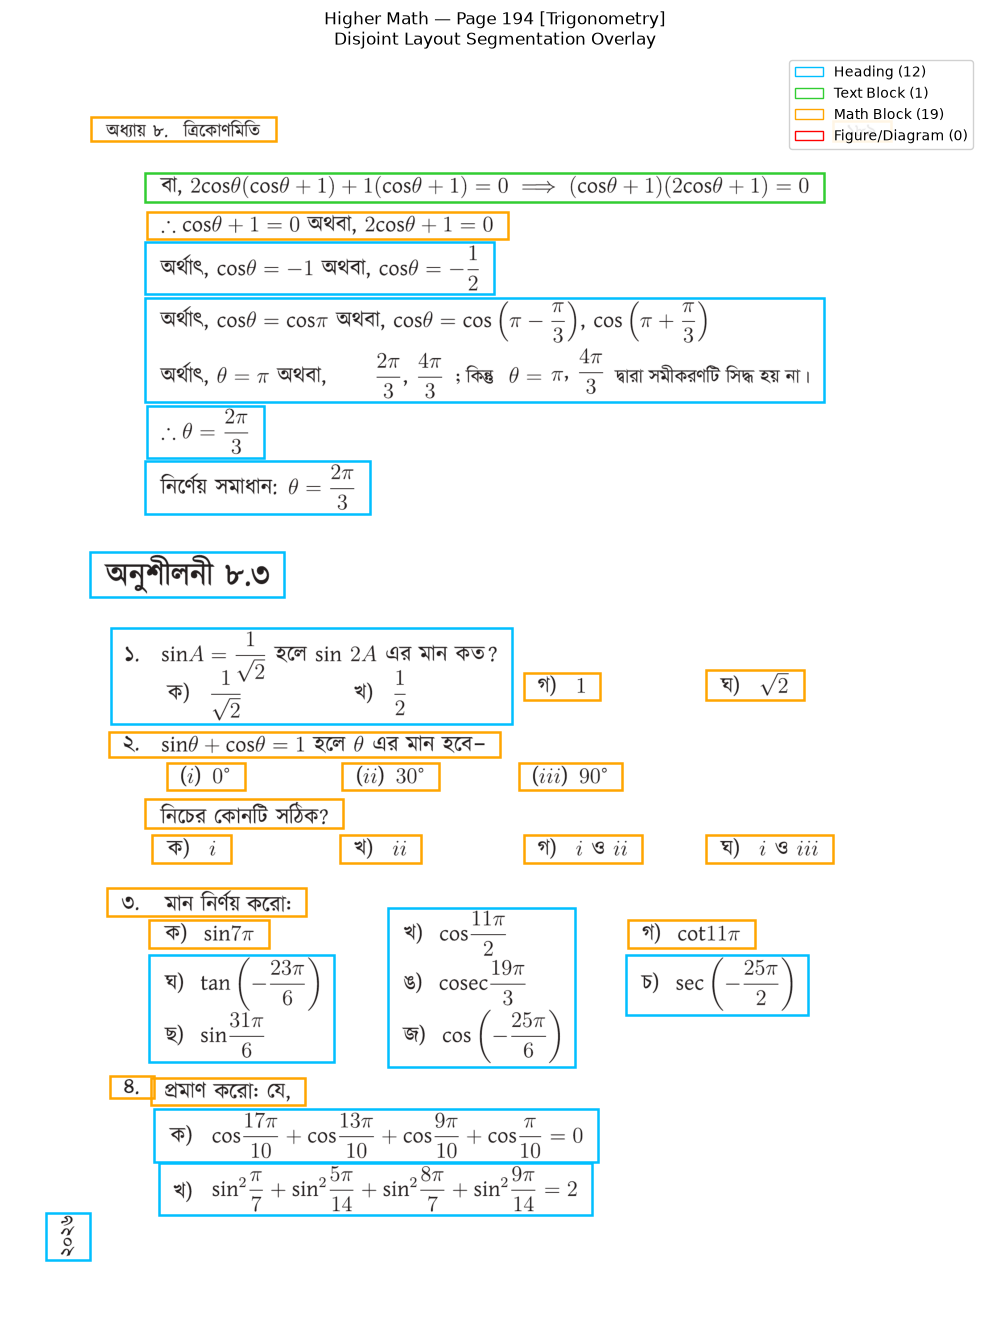

In [ ]:
# Cell 5: Interactive Visual Bounding Box Inspector

def inspect_page_layout(book: str = "Higher Math", page_num: int = 70, show_plot: bool = True):
    """
    Inspects and renders disjoint colored bounding boxes with generous padding for a selected page.
    Colors:
      - Blue   : Heading (Large title text)
      - Green  : Text Block (Prose paragraph lines)
      - Orange : Math Block (Indented/centered equations & fraction steps)
      - Red    : Figure / Diagram (Geometric drawings, plots, and figures)
    """
    prefix = "higher_math_" if book == "Higher Math" else "math_"
    fname = f"{prefix}page_{page_num:04d}.png"
    path = RAW_DATA_DIR / fname
    
    if not path.is_file():
        print(f"File not found: {path}")
        return None
    
    res = segment_page_regions(str(path))
    ch_id, ch_bn, ch_en, content_type = lookup_chapter(book, page_num)
    
    print("=" * 65)
    print(f"PAGE LAYOUT INSPECTOR : {fname}")
    print("=" * 65)
    print(f"Book & Chapter          : {book} | {ch_en}")
    print(f"Category Classification : {content_type}")
    print(f"Detected Regions        : Headings: {res['num_headings']} | Text Blocks: {res['num_text']} | Math Blocks: {res['num_math']} | Figures: {res['num_figures']}")
    print(f"Multi-Label Flags       : has_prose={res['has_prose_text']} | has_math={res['has_display_math']} | has_figures={res['has_figures']}")
    print(f"Estimated Word Count    : ~{res['est_words']} words")
    print("=" * 65)
    
    if show_plot:
        img_rgb = Image.open(path).convert("RGB")
        fig, ax = plt.subplots(1, figsize=(10, 14))
        ax.imshow(img_rgb)
        
        color_map = {"heading": "deepskyblue", "text_block": "limegreen", "math_block": "orange", "figure": "red"}
        
        for r in res["regions"]:
            x, y, w, h = r["bbox"]
            c = color_map.get(r["kind"], "yellow")
            rect = patches.Rectangle((x, y), w, h, linewidth=1.8, edgecolor=c, facecolor='none')
            ax.add_patch(rect)
        
        # Legend items
        legend_patches = [
            patches.Patch(edgecolor='deepskyblue', facecolor='none', label=f'Heading ({res["num_headings"]})'),
            patches.Patch(edgecolor='limegreen', facecolor='none', label=f'Text Block ({res["num_text"]})'),
            patches.Patch(edgecolor='orange', facecolor='none', label=f'Math Block ({res["num_math"]})'),
            patches.Patch(edgecolor='red', facecolor='none', label=f'Figure/Diagram ({res["num_figures"]})')
        ]
        ax.legend(handles=legend_patches, loc='upper right', framealpha=0.9, fontsize=10)
        ax.set_title(f"{book} — Page {page_num} [{ch_en}]\nDisjoint Layout Segmentation Overlay", fontsize=12)
        ax.axis("off")
        plt.tight_layout()
        plt.show()
        
    return res

# Test inspector on sample geometry page with figure and proof (Page 70)
demo_res = inspect_page_layout(book="Higher Math", page_num=156, show_plot=True)


Extracting multi-label layout profiles across 24 active pages...
            MULTI-LABEL LAYOUT DISTRIBUTION SUMMARY
Total Pages Analyzed     : 24
Pages with Prose Text    : 21 (87.5%)
Pages with Math Equations: 24 (100.0%)
Pages with Figures/Plots : 11 (45.8%)
-----------------------------------------------------------------
Average Text Blocks/Page : 4.0
Average Math Blocks/Page : 17.2
Average Figures/Page     : 0.6
Mean Estimated Words/Page: 138.9 ± 49.4
Projected Corpus Words   : ~97,768 words (704 pages)


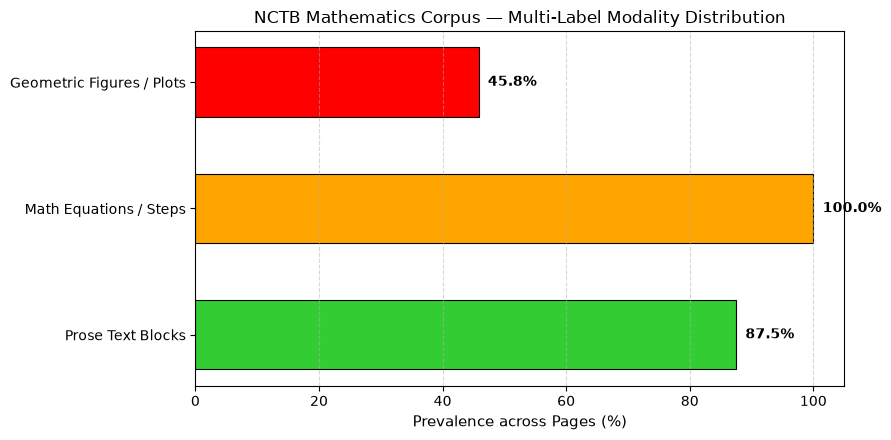

In [6]:
# Cell 6: Corpus-Wide Multi-Label Distribution Summary

print(f"Extracting multi-label layout profiles across {len(active_df)} active pages...")
layout_records = []

for idx, row in active_df.iterrows():
    seg = segment_page_regions(row["path"])
    layout_records.append({
        "filename": row["filename"],
        "book": row["book"],
        "page_num": row["page_num"],
        "chapter": row["chapter_name_en"],
        "content_type": row["content_type"],
        "headings": seg["num_headings"],
        "text_blocks": seg["num_text"],
        "math_blocks": seg["num_math"],
        "figures": seg["num_figures"],
        "has_prose": seg["has_prose_text"],
        "has_math": seg["has_display_math"],
        "has_figures": seg["has_figures"],
        "est_words": seg["est_words"]
    })

df_layout = pd.DataFrame(layout_records)

# Multi-label prevalence rates
pct_prose = (df_layout["has_prose"].sum() / len(df_layout)) * 100
pct_math = (df_layout["has_math"].sum() / len(df_layout)) * 100
pct_figs = (df_layout["has_figures"].sum() / len(df_layout)) * 100

print("=" * 65)
print("            MULTI-LABEL LAYOUT DISTRIBUTION SUMMARY")
print("=" * 65)
print(f"Total Pages Analyzed     : {len(df_layout)}")
print(f"Pages with Prose Text    : {df_layout['has_prose'].sum()} ({pct_prose:.1f}%)")
print(f"Pages with Math Equations: {df_layout['has_math'].sum()} ({pct_math:.1f}%)")
print(f"Pages with Figures/Plots : {df_layout['has_figures'].sum()} ({pct_figs:.1f}%)")
print("-" * 65)
print(f"Average Text Blocks/Page : {df_layout['text_blocks'].mean():.1f}")
print(f"Average Math Blocks/Page : {df_layout['math_blocks'].mean():.1f}")
print(f"Average Figures/Page     : {df_layout['figures'].mean():.1f}")
print(f"Mean Estimated Words/Page: {df_layout['est_words'].mean():.1f} ± {df_layout['est_words'].std():.1f}")
print(f"Projected Corpus Words   : ~{int(df_layout['est_words'].mean() * total_pages):,} words (704 pages)")
print("=" * 65)

# Multi-label prevalence bar chart
labels = ['Prose Text Blocks', 'Math Equations / Steps', 'Geometric Figures / Plots']
percentages = [pct_prose, pct_math, pct_figs]
colors = ['limegreen', 'orange', 'red']

plt.figure(figsize=(9, 4.5))
bars = plt.barh(labels, percentages, color=colors, height=0.55, edgecolor='black', linewidth=0.8)
plt.xlim(0, 105)
plt.xlabel('Prevalence across Pages (%)', fontsize=11)
plt.title('NCTB Mathematics Corpus — Multi-Label Modality Distribution', fontsize=12)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 1.5, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
